# Decision Trees:

This notebook is arranged in the exact order you should study.
Read strictly by section number from top to bottom.

## Recommended Study Flow
1. Core idea of Decision Trees
2. Entropy and Information Gain fundamentals
3. Gini impurity and algorithms (ID3/C4.5/CART)
4. Practical implementation in sklearn
5. Hyperparameters and overfitting control
6. Advanced manual calculations (dataset entropy, IG tables, numeric thresholds)
7. Other important concepts (gain ratio, pruning, feature importance)
8. Revision questions and final summary

---

## Prerequisites
Basic Python and machine learning fundamentals are enough to follow this notebook.

## 1. What Is a Decision Tree?

A Decision Tree is a supervised learning algorithm used for:
- Classification (predicting categories)
- Regression (predicting numerical values)

It works like a flowchart:
- Internal nodes: feature-based questions (for example, `petal_length <= 2.5`)
- Branches: outcomes of each question
- Leaf nodes: final prediction

### Advantages of Decision Trees
- Easy to understand and explain
- Minimal data preprocessing required
- Can capture non-linear relationships
- Works with both numerical and categorical features
- Feature importance can be interpreted from splits

### Disadvantages of Decision Trees
- Can overfit easily if not controlled
- Small data changes may create very different trees
- Standalone trees may be less accurate than ensembles (Random Forest, XGBoost)
- Biased splits can occur when classes are imbalanced
- Greedy splitting may miss globally optimal tree structure
- Not good for imbalanced datasets

## 2. Entropy (Core Theory)

Entropy measures impurity or uncertainty in a dataset.

For binary classification:

$$
Entropy(S) = -p_1\log_2(p_1) - p_2\log_2(p_2)
$$

For multi-class classification:

$$
Entropy(S) = -\sum_{i=1}^{k} p_i \log_2(p_i)
$$

NOTE - We can also use natural log ($log_e$)

Where:
- $p_i$ = proportion of class $i$
- If all samples belong to one class, entropy is $0$ (pure node)
- Higher entropy means more mixed classes

### Quick intuition
- Entropy = 0: completely pure
- Entropy is high: highly mixed

In [1]:
# Entropy implementation from scratch
import numpy as np

def entropy(y):
    """Compute entropy for a 1D array of class labels."""
    # Count labels and convert counts to probabilities
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()

    # Remove zero probabilities to avoid log2(0)
    probabilities = probabilities[probabilities > 0]

    # Apply entropy formula
    return -np.sum(probabilities * np.log2(probabilities))

# Example checks
pure = np.array([1, 1, 1, 1])
mixed = np.array([0, 0, 1, 1])
imbalanced = np.array([0, 0, 0, 1])

print('Entropy (pure):', entropy(pure))
print('Entropy (50-50 mixed):', entropy(mixed))
print('Entropy (imbalanced):', entropy(imbalanced))

Entropy (pure): -0.0
Entropy (50-50 mixed): 1.0
Entropy (imbalanced): 0.8112781244591328


## 4. Information Gain (Core Theory)

Decision Trees choose the split that gives maximum Information Gain.

$$
Information\ Gain = Entropy(Parent) - \sum_{j=1}^{m} \frac{|S_j|}{|S|}Entropy(S_j)
$$

Where:
- $S$ is the parent dataset
- $S_j$ are child subsets after a split
- $m$ is the number of child nodes

A good split makes child nodes purer, reducing entropy.

In [2]:
# Information gain for a binary split (feature <= threshold)
def information_gain_binary_split(X_column, y, threshold):
    """Compute information gain for split: X_column <= threshold."""
    parent_entropy = entropy(y)

    # Split indices
    left_idx = X_column <= threshold
    right_idx = X_column > threshold

    y_left, y_right = y[left_idx], y[right_idx]

    # If any side is empty, split is invalid
    if len(y_left) == 0 or len(y_right) == 0:
        return 0

    # Weighted child entropy
    n = len(y)
    child_entropy = (len(y_left) / n) * entropy(y_left) + (len(y_right) / n) * entropy(y_right)

    return parent_entropy - child_entropy

# Simple demo data
X_demo = np.array([2, 3, 10, 12, 13, 15])
y_demo = np.array([0, 0, 1, 1, 1, 0])

threshold = 11
ig = information_gain_binary_split(X_demo, y_demo, threshold)
print(f'Information Gain at threshold {threshold}: {ig:.4f}')

Information Gain at threshold 11: 0.0817


## 7. Gini Impurity (Theory)

Another popular split criterion is Gini impurity (used by CART(Classification and Regression Trees)).

$$
Gini(S) = 1 - \sum_{i=1}^{k} p_i^2
$$

Interpretation:
- Gini = 0 means pure node
- Higher Gini means more impurity

### Entropy vs Gini
- Both measure impurity
- Both prefer pure splits
- Gini is often slightly faster to compute
- In practice, both usually perform similarly

In [3]:
# Gini implementation from scratch
def gini_impurity(y):
    """Compute Gini impurity for a 1D array of class labels."""
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()
    return 1 - np.sum(probabilities ** 2)

# Compare entropy and gini on different class distributions
sample_sets = {
    'Pure': np.array([1, 1, 1, 1]),
    'Balanced': np.array([0, 0, 1, 1]),
    'Imbalanced': np.array([0, 0, 0, 1])
}

for name, labels in sample_sets.items():
    print(f'{name:10} | Entropy: {entropy(labels):.4f} | Gini: {gini_impurity(labels):.4f}')

Pure       | Entropy: -0.0000 | Gini: 0.0000
Balanced   | Entropy: 1.0000 | Gini: 0.5000
Imbalanced | Entropy: 0.8113 | Gini: 0.3750


## 8. Common Decision Tree Algorithms

- ID3: uses Entropy + Information Gain
- C4.5: extension of ID3, supports continuous features, uses Gain Ratio
- CART: Classification and Regression Trees, usually uses Gini for classification

`scikit-learn`'s `DecisionTreeClassifier` is CART-based.

---

## 9. Practical Implementation with scikit-learn

We will:
1. Load a dataset
2. Split into train and test sets
3. Train a Decision Tree
4. Evaluate model performance

In [4]:
# 1) Import libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2) Load dataset (Iris)
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print('Feature shape:', X.shape)
print('Class labels:', iris.target_names)

Feature shape: (150, 4)
Class labels: ['setosa' 'versicolor' 'virginica']


In [5]:
# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4) Build and train model
model = DecisionTreeClassifier(
    criterion='entropy',   # you can also try 'gini'
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

# 5) Predictions and evaluation
y_pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.9666666666666667

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



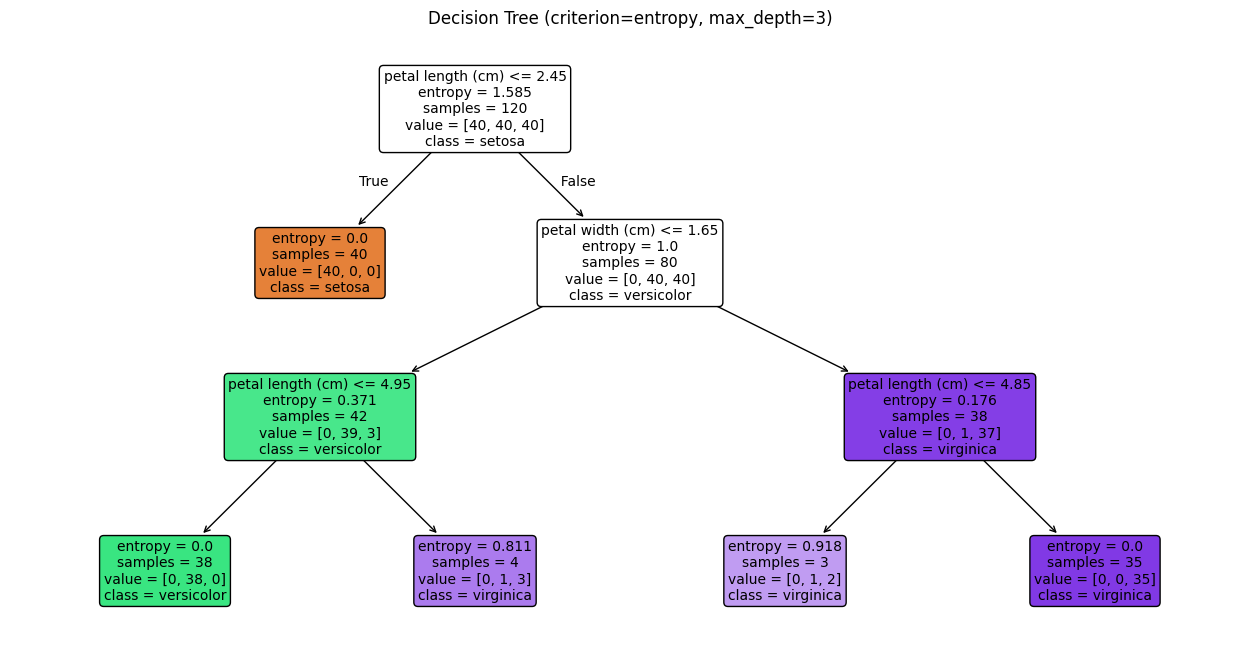

In [6]:
# 6) Visualize the decision tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree (criterion=entropy, max_depth=3)')
plt.show()

## 10. Important Hyperparameters (Easy Guide)

- `criterion`: impurity function (`'gini'` or `'entropy'`)
- `max_depth`: maximum depth of the tree
- `min_samples_split`: minimum samples needed to split a node
- `min_samples_leaf`: minimum samples required in a leaf
- `max_features`: number of features to consider at each split

These control model complexity and help prevent overfitting.

In [7]:
# 8) Simple hyperparameter experiment
results = []

for depth in [1, 2, 3, 4, 5, None]:
    temp_model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        random_state=42
    )
    temp_model.fit(X_train, y_train)
    temp_pred = temp_model.predict(X_test)
    acc = accuracy_score(y_test, temp_pred)
    results.append((depth, acc))

results_df = pd.DataFrame(results, columns=['max_depth', 'accuracy'])
print(results_df)

   max_depth  accuracy
0        1.0  0.666667
1        2.0  0.933333
2        3.0  0.966667
3        4.0  0.933333
4        5.0  0.933333
5        NaN  0.933333


## 11. Overfitting and Pruning

Decision Trees can memorize training data if allowed to grow too deep.

### Signs of overfitting
- Very high training accuracy
- Lower test accuracy

### Ways to reduce overfitting
- Limit depth (`max_depth`)
- Increase `min_samples_split`
- Increase `min_samples_leaf`
- Use pruning-like constraints (pre-pruning in sklearn)

In real projects, tune these with cross-validation.

## 12. How To Find Entropy of a Dataset (Step by Step)

Suppose the target column has two classes:
- Yes: 9
- No: 5

Total samples = 14

So probabilities are:
- $p(Yes)=\frac{9}{14}$
- $p(No)=\frac{5}{14}$

Dataset entropy:

$$
H(S)=-\left(\frac{9}{14}\log_2\frac{9}{14}+\frac{5}{14}\log_2\frac{5}{14}\right)
$$

This gives approximately $0.940$.

Interpretation:
- If entropy is near 1 (binary case), data is mixed.
- If entropy is near 0, data is pure.

We now compute this directly in code for any dataset.

In [8]:
# Utility: entropy from a pandas target column
import numpy as np
import pandas as pd

def entropy_from_series(target_series):
    """Compute entropy of a target column (classification labels)."""
    probabilities = target_series.value_counts(normalize=True).values
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))

# Example toy dataset used in many DT explanations
df_toy = pd.DataFrame({
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Windy':   [False, True, False, False, False, True, True, False, False, False, True, True, False, True],
    'Play':    ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
})

dataset_entropy = entropy_from_series(df_toy['Play'])
print('Dataset Entropy H(S):', round(dataset_entropy, 4))
print('\nClass distribution:\n', df_toy['Play'].value_counts())

Dataset Entropy H(S): 0.9403

Class distribution:
 Play
Yes    9
No     5
Name: count, dtype: int64


## 13. How To Find Information Gain of a Feature

For a feature $X$:

$$
IG(S, X) = H(S) - \sum_{v \in Values(X)}\frac{|S_v|}{|S|}H(S_v)
$$

Where:
- $H(S)$ is parent entropy
- $S_v$ is subset where feature value is $v$

Decision Trees pick the feature with maximum information gain.

Below code computes information gain for categorical features exactly using this formula.

In [9]:
def information_gain_categorical(df, feature_col, target_col):
    """Information gain for a categorical feature."""
    parent_entropy = entropy_from_series(df[target_col])

    weighted_child_entropy = 0.0
    total_count = len(df)

    for value, subset in df.groupby(feature_col):
        weight = len(subset) / total_count
        child_entropy = entropy_from_series(subset[target_col])
        weighted_child_entropy += weight * child_entropy
        print(f'{feature_col}={value:8} | weight={weight:.3f} | entropy={child_entropy:.3f}')

    ig = parent_entropy - weighted_child_entropy
    return ig

ig_outlook = information_gain_categorical(df_toy, 'Outlook', 'Play')
ig_windy = information_gain_categorical(df_toy, 'Windy', 'Play')

print('\nIG(Outlook):', round(ig_outlook, 4))
print('IG(Windy):  ', round(ig_windy, 4))

Outlook=Overcast | weight=0.286 | entropy=-0.000
Outlook=Rain     | weight=0.357 | entropy=0.971
Outlook=Sunny    | weight=0.357 | entropy=0.971
Windy=       0 | weight=0.571 | entropy=0.811
Windy=       1 | weight=0.429 | entropy=1.000

IG(Outlook): 0.2467
IG(Windy):   0.0481


In [10]:
# Compare information gain across all candidate categorical features
candidate_features = ['Outlook', 'Windy']
all_ig = {}

for feature in candidate_features:
    all_ig[feature] = information_gain_categorical(df_toy, feature, 'Play')

ig_table = pd.DataFrame({
    'feature': list(all_ig.keys()),
    'information_gain': list(all_ig.values())
}).sort_values('information_gain', ascending=False)

print('\nFeature ranking by IG:')
print(ig_table)
print('\nBest feature to split first:', ig_table.iloc[0]['feature'])

Outlook=Overcast | weight=0.286 | entropy=-0.000
Outlook=Rain     | weight=0.357 | entropy=0.971
Outlook=Sunny    | weight=0.357 | entropy=0.971
Windy=       0 | weight=0.571 | entropy=0.811
Windy=       1 | weight=0.429 | entropy=1.000

Feature ranking by IG:
   feature  information_gain
0  Outlook          0.246750
1    Windy          0.048127

Best feature to split first: Outlook


## 14. Numeric Features: Best Threshold Split

For numeric features, trees test thresholds like:

$$
X_j \le t
$$

For each threshold $t$, compute impurity after split and choose the best one.

Using entropy criterion, choose threshold with highest information gain.
Using gini criterion, choose threshold with lowest weighted gini.

Below code tries all valid thresholds for one numeric feature and reports the best split.

In [11]:
def best_threshold_by_entropy(X_column, y):
    """Return threshold with maximum information gain for numeric feature."""
    # Candidate thresholds = midpoints between sorted unique values
    unique_values = np.sort(np.unique(X_column))
    thresholds = (unique_values[:-1] + unique_values[1:]) / 2

    best_threshold = None
    best_gain = -1

    for t in thresholds:
        gain = information_gain_binary_split(X_column, y, t)
        if gain > best_gain:
            best_gain = gain
            best_threshold = t

    return best_threshold, best_gain

feature_name = iris.feature_names[2]  # petal length
X_col = X[feature_name].values

best_t, best_ig = best_threshold_by_entropy(X_col, y)
print('Feature:', feature_name)
print('Best threshold by entropy:', round(best_t, 4))
print('Best information gain:', round(best_ig, 4))

Feature: petal length (cm)
Best threshold by entropy: 2.45
Best information gain: 0.9183


## 15. Other Important Decision Tree Concepts Used in Practice

### Gain Ratio (used in C4.5)
Information Gain can favor features with many unique values.
Gain Ratio corrects this:

$$
Gain\ Ratio = \frac{Information\ Gain}{Split\ Information}
$$

where

$$
Split\ Information = -\sum_{v}\frac{|S_v|}{|S|}\log_2\frac{|S_v|}{|S|}
$$

### Regression Trees
For regression targets, trees usually split using variance reduction (MSE-based criterion), not entropy/gini.

### Pre-pruning Parameters
Common controls to prevent overfitting:
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_leaf_nodes`

### Post-pruning in sklearn
Cost complexity pruning uses `ccp_alpha`.
Larger `ccp_alpha` means stronger pruning.

### Feature Importance
Tree models can report feature importance based on impurity reduction, but interpret with care (can be biased).

## 16. Quick Interview/Revision Questions

1. What is entropy in Decision Trees?
2. How is Information Gain computed?
3. Difference between entropy and Gini impurity?
4. Why can Decision Trees overfit?
5. What does `max_depth` control?
6. What is the role of `min_samples_leaf`?
7. Which algorithm does sklearn `DecisionTreeClassifier` follow?

---

## 17. Final Summary

You now have:
- Theory: entropy, information gain, gini, split criteria
- Code from scratch for impurity measures
- End-to-end sklearn implementation
- Practical understanding of hyperparameters and overfitting control